# Threat Index: The Perfect Beach Day

- Application: Is it a good day to go to the beach?
- Audience: General Public

## Choosing Our Scale

- Range: 0 to 10
- 0 = no beach day
- 10 = best beach day possible
- We will construct the index from 0-10.

## Weighting Our Variables

- Precipitation: 40%
- Temperature: 30%
- Wind: 15%
- Cloud cover: 10%
- Dewpoint: 5%

# Figuring Out Individual Contributions

## Temperature Contribution

- 0 when T < 60 °F
- 10 when 75 <= T <= 85
- 2.5 when T >= 100
- Linear slope from 60 to 75
- Constant slope from 75 to 85
- Exponential decay slope from 85 to 100

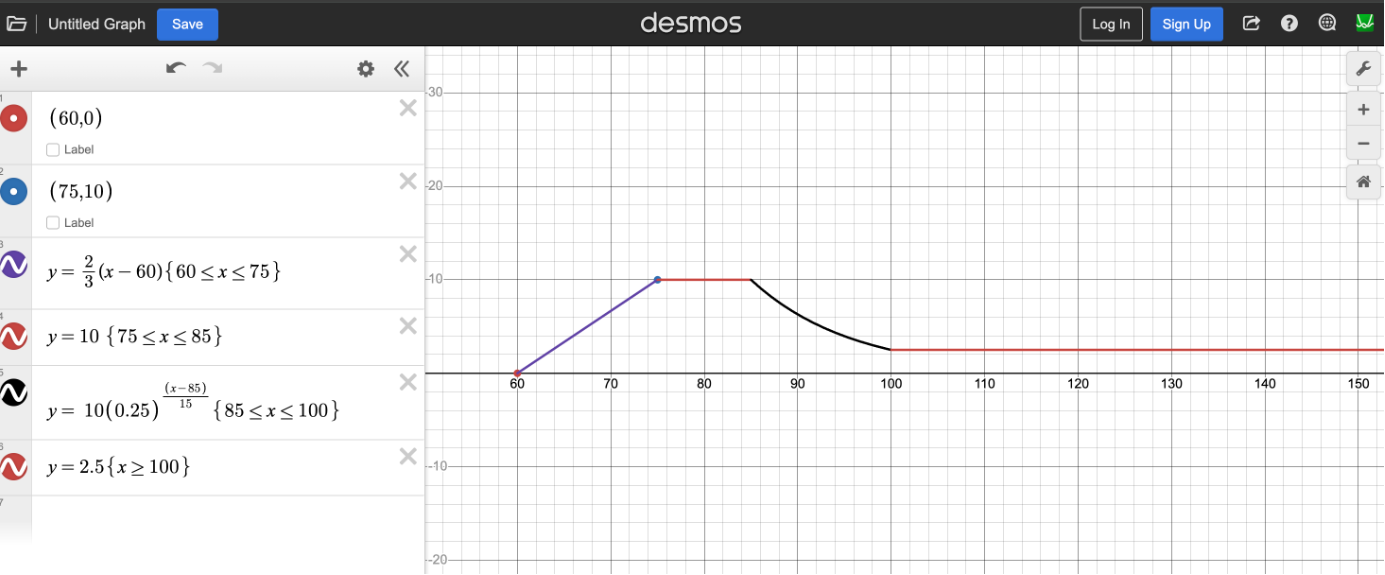

## Precipitation

- 0 when rain chance >= 60%
- 2.5 when 21% <= rain chance <= 40%
- 5 when 41% <= rain chance <= 59%
- 10 when 0% <= rain chance <= 20%
- linear slope between them

## Wind Contribution

- 0 when wind is > 25 mph
- 10 when wind is < 10 mph
- 5 when 11 mph < wind < 24 mph

## Dewpoint Contribution

- 10 when 45 °F <= dewpoint <= 65 °F
- 0 when dewpoint > 85 °F
- 2.5 when 66 °F <= dewpoint <= 85 °F
- 5 when < 45 °F

## Cloud Contribution

- 0 when 80% <= cloud cover <= 100%
- 2.5 when 50% <= cloud cover < 80%
- 10 when 0% <= cloud cover < 25%
- 5 when 25% <= cloud cover < 50%

In [4]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import LinearSegmentedColormap, ListedColormap

In [5]:
#Open Dataset
ds = xr.open_dataset("beachday_new.nc")

sh: 1: getfattr: not found


In [6]:
#Show dataset
ds

<xarray.Dataset> Size: 19MB
Dimensions:            (valid_time: 41, latitude: 101, longitude: 161)
Coordinates:
  * valid_time         (valid_time) datetime64[ns] 328B 2025-07-01T12:00:00 ....
  * latitude           (latitude) float64 808B 50.0 49.75 49.5 ... 25.25 25.0
  * longitude          (longitude) float64 1kB 260.0 260.2 260.5 ... 299.8 300.0
    time               datetime64[ns] 8B ...
    step               (valid_time) timedelta64[ns] 328B ...
    heightAboveGround  float64 8B ...
    surface            float64 8B ...
    atmosphere         float64 8B ...
Data variables:
    t2m                (valid_time, latitude, longitude) float32 3MB ...
    d2m                (valid_time, latitude, longitude) float32 3MB ...
    tp                 (valid_time, latitude, longitude) float32 3MB ...
    tcc                (valid_time, latitude, longitude) float32 3MB ...
    u10                (valid_time, latitude, longitude) float32 3MB ...
    v10                (valid_time, latitude, longitude) float32 3MB ...
    prate              (valid_time, latitude, longitude) float32 3MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    history:                 2026-04-08T15:49 GRIB to CDM+CF via cfgrib-0.9.1...

In [7]:
#Choose forecast hour
ds_time = ds.isel(valid_time=5)

# Temperature Contribution

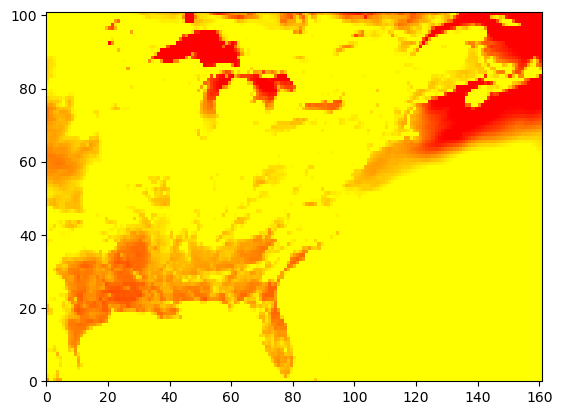

In [8]:
#Extract temperature
temp = ds_time['t2m']

#Convert temperature to Fahrenheit
temp_F = (temp.values - 273.15) * (9/5) + 32
temp_F

#Start with contributions set to 0
temp_contribution = np.zeros_like(temp_F)     #Creates separate array same shape as temp_F

#60 <= T < 75 : linear increase from 0 to 10
mask = (temp_F >= 60) & (temp_F < 75)
temp_contribution[mask] = (2/3) * (temp_F[mask] - 60)

#75 <= T <= 85 : contribution = 10
mask = (temp_F >= 75) & (temp_F <= 85)
temp_contribution[mask] = 10.0

#85 < T < 100 : linear decrease from 10 to 5
mask = (temp_F > 85) & (temp_F < 100)
temp_contribution[mask] = 10.0 * (0.25 ** ((temp_F[mask] - 85) / 15))

#T >= 100 : contribution = 2.5
mask = temp_F >= 100
temp_contribution[mask] = 2.5

#Index map
plt.pcolormesh(np.flipud(temp_contribution), cmap='autumn')

# Dewpoint Contribution

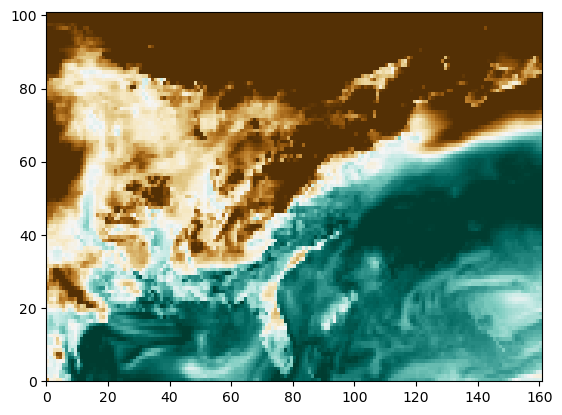

In [9]:
#Extract dewpoint
dewpoint = ds_time['d2m']

#Convert dewpoint to Fahrenheit
dewpoint_F = (dewpoint.values - 273.15)*(9/5) + 32
dewpoint_F.max() 

#Start with contributions set to 0
dewpoint_contribution = np.zeros_like(dewpoint_F)

#60 <= dewpoint < 75
mask = (dewpoint_F >= 60) & (dewpoint_F < 75)
dewpoint_contribution[mask] = (2/3)*(dewpoint_F[mask] - 60)

#75 <= dewpoint <= 85
mask = (dewpoint_F >= 75) & (dewpoint_F <= 85)
dewpoint_contribution[mask] = 10.0

#85 < dewpoint < 100
mask = (dewpoint_F > 85) & (dewpoint_F < 100)
dewpoint_contribution[mask] = 10*(0.25)**((dewpoint_F[mask]-85)/15) 

#Dewpoint >= 100
mask = dewpoint_F >= 100
dewpoint_contribution[mask] = 2.5

#Index map
plt.pcolormesh(np.flipud(dewpoint_contribution), cmap='BrBG')

# Cloud Cover Contribution

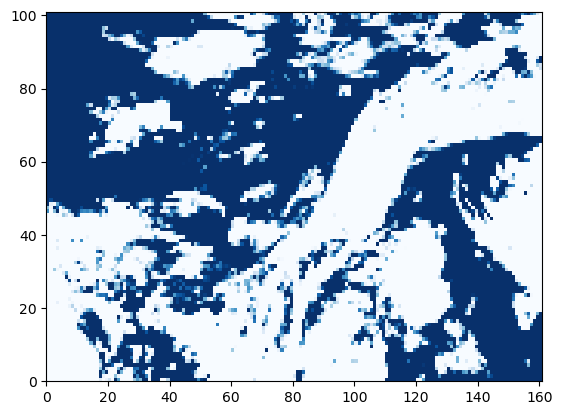

In [10]:
totalcloud = (ds_time['tcc'].values)
totalcloud.max() 

cloud_contribution = np.zeros_like(totalcloud)


mask = (totalcloud >= 0) & (totalcloud <= 35)
cloud_contribution[mask] = 10

mask = (totalcloud > 35) & (totalcloud < 80)
cloud_contribution[mask] = ((-2/9)*(totalcloud[mask]))+(160/9)


mask = (totalcloud >= 80) & (totalcloud <= 100)
cloud_contribution[mask] = 0

plt.pcolormesh(np.flipud(cloud_contribution), cmap='Blues')

# Wind Contribution

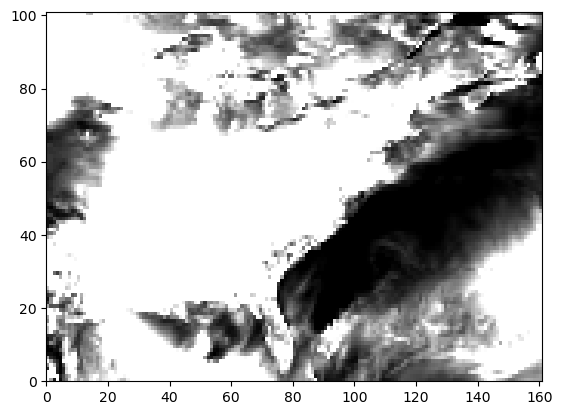

In [11]:
u=(ds_time['u10'].values)
v=(ds_time['v10'].values)

wind= np.sqrt(u**2+v**2)
wind_mph= wind*2.23693629 

wind_mph.max()

wind_contribution = np.zeros_like(wind_mph)


mask = (wind_mph >= 0) & (wind_mph < 10)
wind_contribution[mask] = 10

mask = (wind_mph > 10) & (wind_mph < 20)
wind_contribution[mask] =121*np.exp(-0.24*(wind_mph[mask]))-1


mask = (wind_mph >= 20) 
wind_contribution[mask] = 0

plt.pcolormesh(np.flipud(wind_contribution), cmap='gray')

# Precipitation Contribution

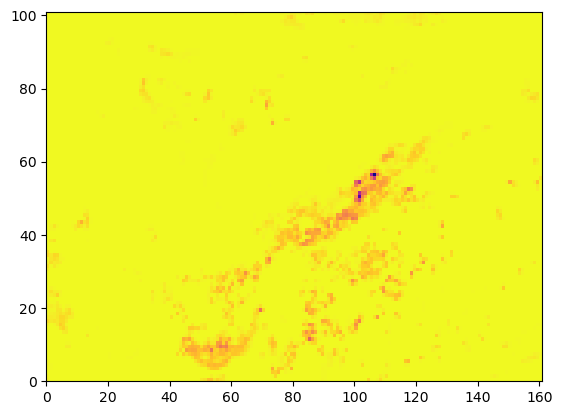

In [12]:
preciprate = (ds_time['prate'].values)
prate_mm_hr = preciprate*3600
prate_in_hr= prate_mm_hr*0.0393701
prate_in_hr.max() 

precip_contribution = np.zeros_like(preciprate)

mask = (preciprate >= 0) & (preciprate <= 0.2)
precip_contribution[mask] = (-50*(preciprate[mask]))+10

plt.pcolormesh(np.flipud(precip_contribution), cmap='plasma')

In [13]:
def beachday_index(ds,ts):
    ds_time=ds.isel(valid_time=ts)

    temp_f = (ds_time['t2m'].values - 273.15)*(9/5) + 32
    temp_contribution = np.zeros_like(temp_f)
    mask = (temp_f >= 60) & (temp_f < 75)
    temp_contribution[mask] = (2/3)*(temp_f[mask] - 60)
    mask = (temp_f >= 75) & (temp_f <= 85)
    temp_contribution[mask] = 10.0
    mask = (temp_f > 85) & (temp_f < 100)
    temp_contribution[mask] = 10*(0.25)**((temp_f[mask]-85)/15) 
    mask = temp_f >= 100
    temp_contribution[mask] = 2.5

    dewpoint_f = (ds_time['d2m'].values - 273.15)*(9/5) + 32
    dewpoint_f.max() 
    dewpoint_contribution = np.zeros_like(dewpoint_f)
    mask = (dewpoint_f<45)
    dewpoint_contribution[mask]=2.5
    mask = (dewpoint_f >= 45) & (dewpoint_f < 55)
    dewpoint_contribution[mask] = 0.004488*(1.1487)**(dewpoint_f[mask])
    mask = (dewpoint_f >= 55) & (dewpoint_f <= 75)
    dewpoint_contribution[mask] = 10.0
    mask = (dewpoint_f > 75) & (dewpoint_f < 85)
    dewpoint_contribution[mask] = 11*np.exp(-0.2398*(dewpoint_f[mask]-75))-1
    mask = dewpoint_f >= 85
    dewpoint_contribution[mask] = 0

    totalcloud = (ds_time['tcc'].values)
    totalcloud.max() 
    cloud_contribution = np.zeros_like(totalcloud)
    mask = (totalcloud >= 0) & (totalcloud <= 35)
    cloud_contribution[mask] = 10
    mask = (totalcloud > 35) & (totalcloud < 80)
    cloud_contribution[mask] = ((-2/9)*(totalcloud[mask]))+(160/9)
    mask = (totalcloud >= 80) & (totalcloud <= 100)
    cloud_contribution[mask] = 0

    u=(ds_time['u10'].values)
    v=(ds_time['v10'].values)
    wind= np.sqrt(u**2+v**2)
    wind_mph= wind*2.23693629 
    wind_mph.max()
    wind_contribution = np.zeros_like(wind_mph)
    mask = (wind_mph >= 0) & (wind_mph < 10)
    wind_contribution[mask] = 10
    mask = (wind_mph > 10) & (wind_mph < 20)
    wind_contribution[mask] =121*np.exp(-0.24*(wind_mph[mask]))-1
    mask = (wind_mph >= 20) 
    wind_contribution[mask] = 0
    mask = wind_contribution < 0
    wind_contribution[mask] = 0

    prate_mm = ds_time['prate'].values
    prate_mm_hr = prate_mm*3600
    prate_in_hr = prate_mm_hr*0.0393701
    precip_contribution = np.zeros_like(prate_in_hr)
    mask = (prate_in_hr >= 0) & (prate_in_hr <= 0.2)
    precip_contribution[mask] = (-50*(prate_in_hr[mask]))+10

    BD_index = (temp_contribution*0.3+dewpoint_contribution*.005+cloud_contribution*.10+wind_contribution*.15+precip_contribution*.40)
    return BD_index, temp_contribution, dewpoint_contribution, cloud_contribution, wind_contribution, precip_contribution

In [14]:
timestep=5
init_time = pd.to_datetime(ds.time.values).strftime('%HZ %a %b %d %Y')
valid_time = pd.to_datetime(ds.valid_time.values[timestep]).strftime('%HZ %a %b %d %Y')
bd,temp,dewpoint,cloud,wind,precip=beachday_index(ds,timestep)

# Creating Our Maps
- We need six subplots

In [15]:
#Define function
def six_plots(init_time, valid_time):
    #2-by-3 panel plot
    fig = plt.figure(figsize=(20, 20))
    ax_1 = fig.add_subplot(3, 2, 1, projection=ccrs.PlateCarree())
    ax_2 = fig.add_subplot(3, 2, 2, projection=ccrs.PlateCarree())
    ax_3 = fig.add_subplot(3, 2, 3, projection=ccrs.PlateCarree())
    ax_4 = fig.add_subplot(3, 2, 4, projection=ccrs.PlateCarree())
    ax_5 = fig.add_subplot(3, 2, 5, projection=ccrs.PlateCarree())
    ax_6 = fig.add_subplot(3, 2, 6, projection=ccrs.PlateCarree())
    fig.suptitle("Beach Day Index and Parameters", fontsize=20, y=1.183)

    #Set levels
    levels = np.arange(0, 10.25, 0.25)
    
    #Subplot 1: Precipitation
    ax_1.set_title("Precipitation Contribution to Overall Index", loc='left', fontsize=16)
    ax_1.set_title(f'Init: {init_time}\n Valid: {valid_time}', loc='right', fontsize=16)
    ax_1.add_feature(cfeature.COASTLINE)
    ax_1.add_feature(cfeature.BORDERS)
    ax_1.add_feature(cfeature.STATES)
    ax_1.set_extent([-100, -60, 25, 50], crs=ccrs.PlateCarree())
    precip_map = ax_1.contourf(ds['longitude'].values, ds['latitude'].values, precip, levels=levels, cmap='RdYlGn', transform=ccrs.PlateCarree())
    
    #Subplot 2: Temperature
    ax_2.set_title("Temperature Contribution to Overall Index", loc='left', fontsize=16)
    ax_2.set_title(f'Init: {init_time}\n Valid: {valid_time}', loc='right', fontsize=16)
    ax_2.add_feature(cfeature.COASTLINE)
    ax_2.add_feature(cfeature.BORDERS)
    ax_2.add_feature(cfeature.STATES)
    ax_2.set_extent([-100, -60, 25, 50], crs=ccrs.PlateCarree())
    ax_2.contourf(ds['longitude'].values, ds['latitude'].values, temp, levels=levels, cmap='RdYlGn', transform=ccrs.PlateCarree())
    
    #Subplot 3: Wind
    ax_3.set_title("Wind Contribution to Overall Index", loc='left', fontsize=16)
    ax_3.set_title(f'Init: {init_time}\n Valid: {valid_time}', loc='right', fontsize=16)
    ax_3.add_feature(cfeature.COASTLINE)
    ax_3.add_feature(cfeature.BORDERS)
    ax_3.add_feature(cfeature.STATES)
    ax_3.set_extent([-100, -60, 25, 50], crs=ccrs.PlateCarree())
    ax_3.contourf(ds['longitude'].values, ds['latitude'].values, wind, levels=levels, cmap='RdYlGn', transform=ccrs.PlateCarree())
    
    #Subplot 4: Cloud Cover
    ax_4.set_title("Cloud Cover Contribution to Overall Index", loc='left', fontsize=16)
    ax_4.set_title(f'Init: {init_time}\n Valid: {valid_time}', loc='right', fontsize=16)
    ax_4.add_feature(cfeature.COASTLINE)
    ax_4.add_feature(cfeature.BORDERS)
    ax_4.add_feature(cfeature.STATES)
    ax_4.set_extent([-100, -60, 25, 50], crs=ccrs.PlateCarree())
    ax_4.contourf(ds['longitude'].values, ds['latitude'].values, cloud, levels=levels, cmap='RdYlGn', transform=ccrs.PlateCarree())
    
    #Subplot 5: Dewpoint
    ax_5.set_title("Dewpoint Contribution to Overall Index", loc='left', fontsize=16)
    ax_5.set_title(f'Init: {init_time}\n Valid: {valid_time}', loc='right', fontsize=16)
    ax_5.add_feature(cfeature.COASTLINE)
    ax_5.add_feature(cfeature.BORDERS)
    ax_5.add_feature(cfeature.STATES)
    ax_5.set_extent([-100, -60, 25, 50], crs=ccrs.PlateCarree())
    ax_5.contourf(ds['longitude'].values, ds['latitude'].values, dewpoint, levels=levels, cmap='RdYlGn', transform=ccrs.PlateCarree())
    
    #Subplot 6: Overall Index
    ax_6.set_title("Total Beach Day Index", loc='left', fontsize=16)
    ax_6.set_title(f'Init: {init_time}\n Valid: {valid_time}', loc='right', fontsize=16)
    ax_6.add_feature(cfeature.COASTLINE)
    ax_6.add_feature(cfeature.BORDERS)
    ax_6.add_feature(cfeature.STATES)
    ax_6.set_extent([-100, -60, 25, 50], crs=ccrs.PlateCarree())
    ax_6.contourf(ds['longitude'].values, ds['latitude'].values, bd, levels=levels, cmap='RdYlGn', transform=ccrs.PlateCarree())
    
    #Fix layout issues
    plt.tight_layout(rect=[0, 0.05, 1, 1.19])     #Reserves space for individual titles

    #Colorbar
    cbar = fig.colorbar(precip_map, ax=[ax_1, ax_2, ax_3, ax_4, ax_5, ax_6], orientation='horizontal', pad=0.03, fraction=0.0495)
    cbar.set_label("Contribution to Beach Day Index", fontsize=16)
    
    #Show figure
    plt.show()

In [21]:
#Create plotting function for threat index only
def plot_index(ds, bd, timestep, init_time, valid_time, save=True):
    #Create plot and colorbar
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
    ax.set_title("Beach Day Index", loc='left', fontsize=12)
    ax.set_title(f'Init: {init_time}\nValid: {valid_time}', loc='right', fontsize=12)
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS)
    ax.add_feature(cfeature.STATES)
    ax.set_extent([-100, -60, 25, 50], crs=ccrs.PlateCarree())
    levels = np.arange(0, 10.25, 0.25)
    final_index = ax.contourf(ds['longitude'].values, ds['latitude'].values, bd, levels=levels, cmap='RdYlGn', transform=ccrs.PlateCarree())
    index_cb = fig.colorbar(final_index, ax=ax, orientation='horizontal', pad=0.05)
    plt.tight_layout()

    #Save figure as .png file
    if save:
        file_name = f"final_index_{timestep:03d}.png"
        plt.savefig(file_name, dpi=150)
        plt.close(fig)
    else:
        plt.show()

In [22]:
#Loop through all timesteps
for t in range(ds.dims['valid_time']):
    bd, temp, dewpoint, cloud, wind, precip = beachday_index(ds, t)
    valid_time = pd.to_datetime(ds.valid_time.values[t]).strftime('%HZ %b %d %Y')
    plot_index(ds, bd, t, init_time, valid_time)

/tmp/ipykernel_1124889/2665694214.py:2: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for t in range(ds.dims['valid_time']):
